# Klassificering av ansiktsuttryck med Deep Learning

## Introduktion

I denna uppgift bygger jag en CNN-modell (Convolutional Neural Network) för att klassificera ansiktsuttryck med hjälp av FER-2013-datasetet.

Målet är att undersöka hur väl en djupinlärningsmodell kan lära sig att känna igen olika känslor från bilder av ansikten.

Arbetet följer uppgiftens struktur:

1. Förstå datan
2. Förbereda datan
3. Bygga modellen
4. Träna modellen
5. Utvärdera modellen
6. Göra prediktioner på ny data
7. Analysera resultatet
8. Reflektera över arbetet

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

## 1. Förstå datan

I detta steg undersöker jag datasetet innan modellen byggs.

Jag kontrollerar:
- vilka klasser som finns i träningsdatan
- hur många bilder som finns i varje klass
- om datan verkar balanserad eller obalanserad

In [6]:
train_dir = "../data/FER-2013/train"
test_dir = "../data/FER-2013/test"

print("Train-mapp:", train_dir)
print("Test-mapp:", test_dir)

Train-mapp: ../data/FER-2013/train
Test-mapp: ../data/FER-2013/test


In [7]:
classes = os.listdir(train_dir)

print("Klasser i datasetet:")
print(classes)
print()
print("Antal klasser:", len(classes))

Klasser i datasetet:
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Antal klasser: 7


In [8]:
class_counts = {}

for class_name in classes:
    class_path = os.path.join(train_dir, class_name)
    num_images = len(os.listdir(class_path))
    class_counts[class_name] = num_images

print("Antal bilder per klass:\n")

for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")

Antal bilder per klass:

angry: 3995
disgust: 436
fear: 4097
happy: 7215
neutral: 4965
sad: 4830
surprise: 3171


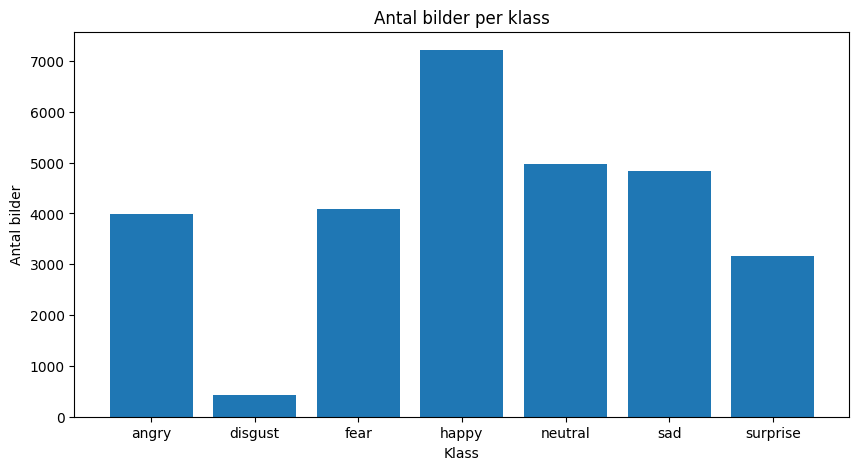

In [9]:
plt.figure(figsize=(10, 5))
plt.bar(class_counts.keys(), class_counts.values())

plt.title("Antal bilder per klass")
plt.xlabel("Klass")
plt.ylabel("Antal bilder")

plt.show()

### Analys av datan

Datasetet innehåller sju olika klasser:

- angry
- disgust
- fear
- happy
- neutral
- sad
- surprise

Antalet bilder skiljer sig mellan klasserna. Klassen happy innehåller flest bilder (7215), medan disgust innehåller betydligt färre bilder (436).

Detta innebär att datasetet är obalanserat. Modellen kommer att få fler exempel att lära sig från vissa klasser än andra, vilket kan påverka resultatet.

Trots detta innehåller de flesta klasser flera tusen bilder, vilket ger goda förutsättningar för att träna en CNN-modell.

## 2. Förbered datan

I detta steg förbereder jag bilderna för träning av modellen.

Jag kommer att:
- läsa in bilderna
- normalisera pixelvärdena
- skapa tränings- och valideringsdata
- kontrollera att bilderna läses in korrekt

In [10]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [11]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(48, 48),
    batch_size=32,
    class_mode="categorical",
    subset="training"
)

validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(48, 48),
    batch_size=32,
    class_mode="categorical",
    subset="validation"
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(48, 48),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


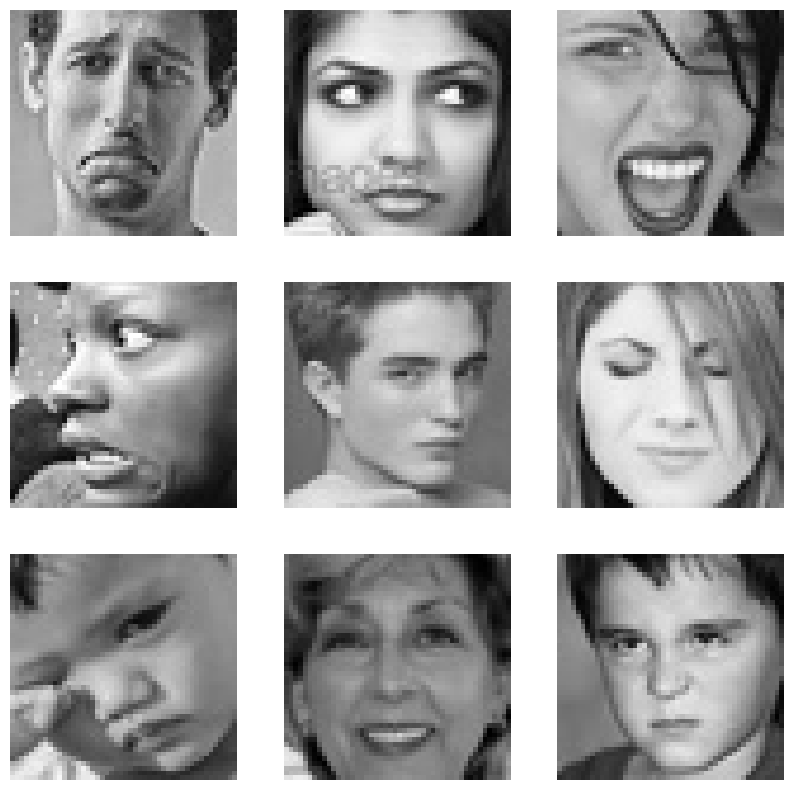

In [12]:
images, labels = next(train_generator)

plt.figure(figsize=(10, 10))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.axis("off")

plt.show()

### Kontroll av inläsning

För att säkerställa att bilderna lästes in korrekt visades ett antal exempelbilder från träningsdatan.

Bilderna visas i gråskala med storleken 48x48 pixlar. Bilderna har även normaliserats så att pixelvärdena ligger mellan 0 och 1.

Kontrollen visar att bilderna kan läsas in korrekt och att datan är redo att användas för träning av modellen.

## 3. Bygga modellen

I detta steg bygger jag en CNN-modell (Convolutional Neural Network) som ska lära sig att klassificera ansiktsuttryck.

Modellen består av:
- konvolutionslager (Conv2D) för att hitta mönster i bilderna
- poolinglager (MaxPooling2D) för att minska mängden data
- dense-lager för klassificering
- ett output-lager med sju neuroner, en för varje klass